In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Use an existing colormap
base_cmap = plt.cm.viridis


# Create a new colormap from the existing colormap
# Start with fully transparent and gradually become opaque
cmap_with_transparency = mcolors.LinearSegmentedColormap.from_list(
    name='transparent_viridis',
    colors=[(0, 0, 0, 0)] + [(c[0], c[1], c[2], i / 256) for i, c in enumerate(base_cmap(np.arange(256)))],
    N=256
)


from matplotlib.colors import LinearSegmentedColormap

# Define the colors for the colormap (white for near zero, black otherwise)
colors = [(0, 0, 0), (1, 1, 1), (0, 0, 0)]  # Black -> White -> Black

# Define the positions of the colors (0.5 is the midpoint)
position = [0, 0.5, 1]

# Create the custom colormap
custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', list(zip(position, colors)))

PAD = np.load("PAD.npy")


E_vals = PAD[0,:]
theta_vals = PAD[1,:]
phi_vals = PAD[2,:]
pad_vals = PAD[3,:]
pad_vals = np.real(pad_vals)


x_vals = E_vals * np.sin(theta_vals) * np.cos(phi_vals)
y_vals = E_vals * np.sin(theta_vals) * np.sin(theta_vals)
z_vals = E_vals * np.cos(theta_vals)




FileNotFoundError: [Errno 2] No such file or directory: 'PAD.npy'

(0.0, 1.0)

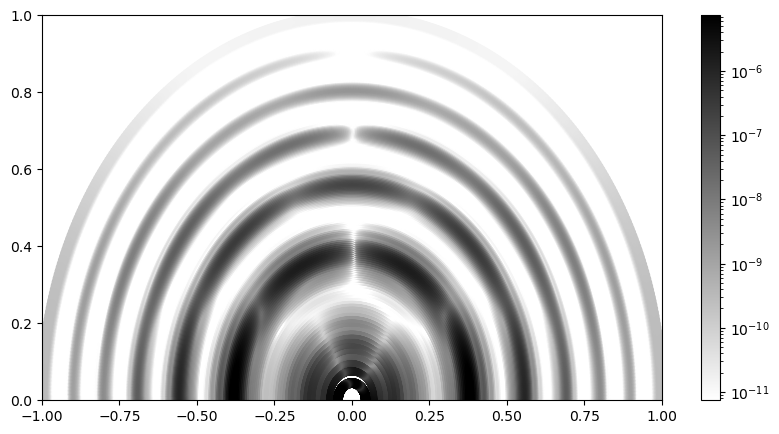

In [11]:
# Momentum Transform
px_vals = np.sqrt(2*E_vals) * np.sin(theta_vals) * np.cos(phi_vals)
py_vals = np.sqrt(2*E_vals) * np.sin(theta_vals) * np.sin(theta_vals)
pz_vals = np.sqrt(2*E_vals) * np.cos(theta_vals)
pad_momentum = pad_vals/np.sqrt(2*E_vals)


plt.figure(figsize=(10, 5)) 

plt.scatter(pz_vals,px_vals,c=pad_momentum, cmap="binary", norm=mcolors.LogNorm(vmin=10**(-11.13), vmax=10**(-5.13)))
#plt.scatter(pz_vals,px_vals,c=np.real(pad_momentum), cmap="bwr", norm=mcolors.LogNorm())
plt.colorbar()

plt.xlim([-1,1])
plt.ylim([0,1])


/users/becker/dopl4670/miniconda3/envs/TDSE/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


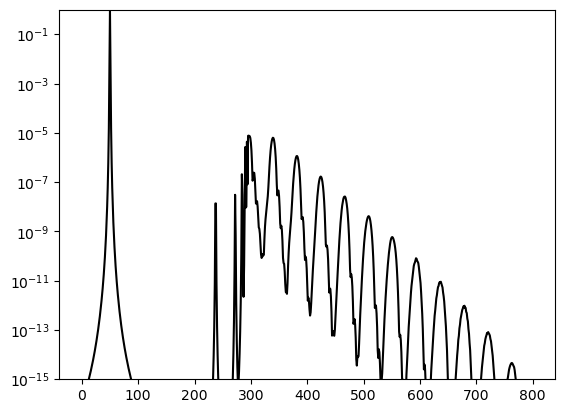

In [4]:
E_range = np.arange(-0.6,1+0.002,0.002)

PES = np.load("PES.npy")
plt.ylim([1E-15,1E0])
plt.semilogy(PES,color = "k")

In [2]:
from petsc4py import PETSc

--------------------------------------------------------------------------
but there are no active ports detected (or Open MPI was unable to use
them).  This is most certainly not what you wanted.  Check your
cables, subnet manager configuration, etc.  The openib BTL will be
ignored for this job.

  Local host: terra
--------------------------------------------------------------------------


In [13]:
H = PETSc.Mat().createAIJ([21*1490,21*1490],nnz =(2*8 + 1))
viewer = PETSc.Viewer().createBinary('../Sample/matrix_files/H_0.bin', 'r')
H.load(viewer)
viewer.destroy()

In [14]:
test = H.getRow(100)

In [15]:
print(len(test[1]))

15
